# Behavioural sequence analysis
This script is used to check the behavioural sequences and quickly see what they look like
The existing code can easily duplicated in additional cells to check other aspects of the 'parameters_per_stimuli' file

In [222]:
import pandas as pd
import os
import matplotlib.pyplot as plt

import seaborn as sns # Loads in the theme
#pd.set_option('display.max_rows', None)

In [223]:
# Make output folder if non-existent
output_dir = os.path.join('..','..','plots','sequences')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
# Make presentations output folder if non-existent
presentations_output_dir = os.path.join('..','..','plots','presentations')
if not os.path.exists(presentations_output_dir):
    os.makedirs(presentations_output_dir)

In [224]:
# Load the path and read the CSV
subject_id = [0]
session_number = [4]
experiment_output_path = os.path.join('/Volumes', 'project', '3025011.02', 'phd_1_task', 'experiment_output')

sequence_path = os.path.join('/Volumes', 'project', '3025011.02', 'phd_1_task', 'sequences', f'parameters_per_stimuli_sub-{subject_id[0]:003}_session-{session_number[0]:02}.csv')
sequence_dataframe = pd.read_csv(sequence_path, sep=';')

#filename = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files',  f'experiment_output_sub-{subject_id[0]:003}_session-{session_number[0]:02}_computer_and_keyboard_2024-06-12_18-02-24.csv')
#pd.read_csv(filename, sep=';')

# Adding a helper column 'entry' to keep track of the count of each type
sequence_dataframe['trial'] = sequence_dataframe.groupby('stimuli_type').cumcount()
unique_stimuli_types = sorted(sequence_dataframe['stimuli_type'].unique())

# Pivot the DataFrame using the new 'entry' column as the index
probability_dataframe_pivoted = sequence_dataframe.pivot(index = 'trial', columns = 'stimuli_type', values = 'probability_condition')

In [225]:
# Determine if there's a change in any column from the previous row
probability_dataframe_pivoted['change'] = probability_dataframe_pivoted[unique_stimuli_types].ne(probability_dataframe_pivoted[unique_stimuli_types].shift()).any(axis=1)

# Assigning a block ID for each group of unchanged rows
probability_dataframe_pivoted['block_id'] = probability_dataframe_pivoted['change'].cumsum()

# Counting rows since the last change
probability_dataframe_pivoted['rows_since_change'] = probability_dataframe_pivoted.groupby('block_id').cumcount()

# Optionally, remove the helper columns
probability_dataframe_pivoted.drop(columns=['change', 'block_id'], inplace=True)

# Print to check
print(probability_dataframe_pivoted)

stimuli_type   1   2  rows_since_change
trial                                  
0             50  50                  0
1             50  50                  1
2             50  50                  2
3             50  50                  3
4             80  20                  0
...           ..  ..                ...
329           80  20                  1
330           80  20                  2
331           80  20                  3
332           80  20                  4
333           80  20                  5

[334 rows x 3 columns]


## Probability sequence
### Plot all probability sequences together
As seen in Ly's paper from 2014

In [226]:
# Total duration based on trial_duration
total_duration = sum(sequence_dataframe['trial_duration'])
average_trial_duration = (sequence_dataframe['trial_duration']).mean()

print(f'trial_duration: {average_trial_duration}s, duration: {total_duration/60}min')

trial_duration: 4.3293413173652695s, duration: 48.2min


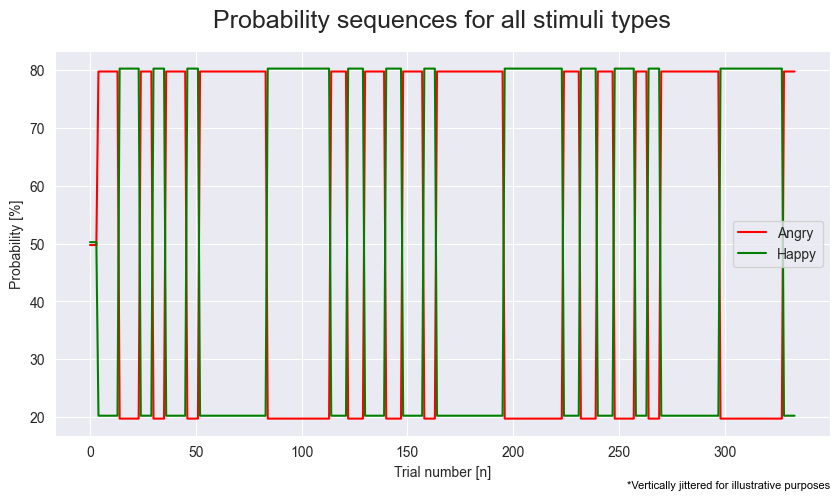

In [227]:
# Jitter vertically to make the lines easier to read when overlapping
jitter_strength = [0.25, -0.25]
stimuli_type_names = ['Angry','Happy']
group_colours = ['red','green']
note = '*Vertically jittered for illustrative purposes'
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(10, 5))
for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value] + jitter_strength[index-1]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value-1])
plt.title('Probability sequences for all stimuli types', fontsize=18, y=1.04)
plt.xlabel('Trial number [n]')
plt.ylabel('Probability [%]')
plt.legend()
plt.text(1, -0.14, note, transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom',
         fontsize=8, color='black')
plt.savefig(os.path.join(output_dir, f'probability_sequence_all_stimuli_types_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()

# Plot the sequence for presentations

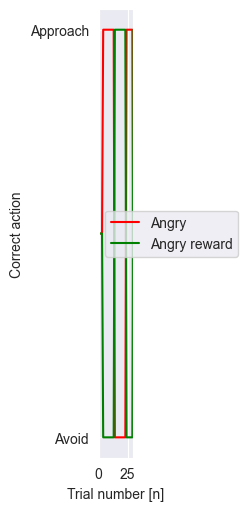

In [228]:
# Jitter vertically to make the lines easier to read when overlapping
stimuli_type_names = ['Angry','Angry reward','Happy','Happy reward']
group_colours = ['red','red','green','green']
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(2.2, 5), constrained_layout=True)
ax.set_yticks([20, 80])
ax.set_yticklabels(['Avoid', 'Approach'])
ax.set_xlim(0, 30)

for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value])
plt.xlabel('Trial number [n]')
plt.ylabel('Correct action')
plt.legend()
plt.savefig(os.path.join(presentations_output_dir, f'sequence_stable_halved_only.pdf'))
plt.show()

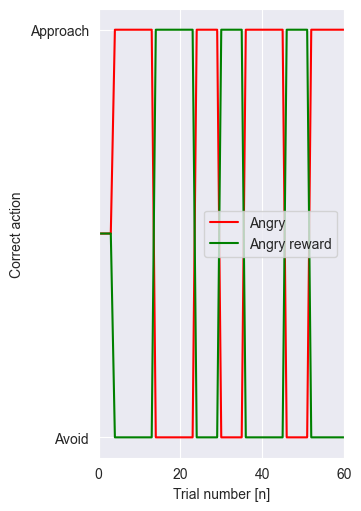

In [229]:
# Jitter vertically to make the lines easier to read when overlapping
stimuli_type_names = ['Angry','Angry reward','Happy','Happy reward']
group_colours = ['red','red','green','green']
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(3.5, 5), constrained_layout=True)
ax.set_yticks([20, 80])
ax.set_yticklabels(['Avoid', 'Approach'])
ax.set_xlim(0, 60)

for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value])
plt.xlabel('Trial number [n]')
plt.ylabel('Correct action')
plt.legend()
plt.savefig(os.path.join(presentations_output_dir, f'sequence_stable_only.pdf'))
plt.show()

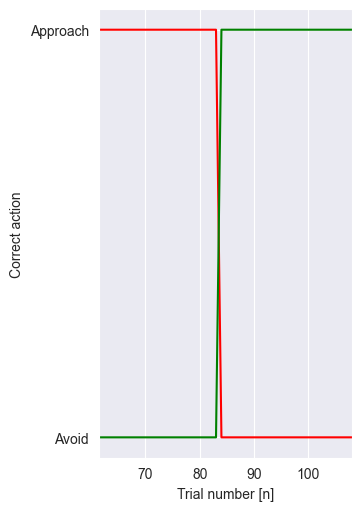

In [230]:
# Jitter vertically to make the lines easier to read when overlapping
stimuli_type_names = ['Angry','Angry reward','Happy','Happy reward']
group_colours = ['red','red','green','green']
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(3.5, 5), constrained_layout=True)
ax.set_yticks([20, 80])
ax.set_yticklabels(['Avoid', 'Approach'])
ax.set_xlim(61.35, 108)

for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value])
plt.xlabel('Trial number [n]')
plt.ylabel('Correct action')
plt.savefig(os.path.join(presentations_output_dir, f'sequence_volatile_only.pdf'))
plt.show()

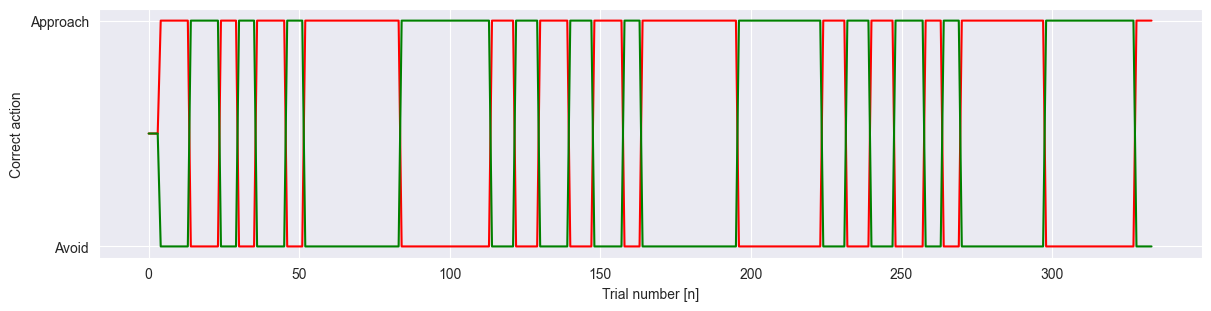

In [231]:
# Jitter vertically to make the lines easier to read when overlapping
stimuli_type_names = ['Angry','Angry reward','Happy','Happy reward']
group_colours = ['red','red','green','green']
# Plot all stimuli types together
fig, ax = plt.subplots(figsize=(12, 3), constrained_layout=True)
ax.set_yticks([20, 80])
ax.set_yticklabels(['Avoid', 'Approach'])
#ax.set_xlim(0, 108)

for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value]
    plt.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value])
plt.xlabel('Trial number [n]')
plt.ylabel('Correct action')
plt.savefig(os.path.join(presentations_output_dir, f'sequence_stable_and_volatile.pdf'))
plt.show()

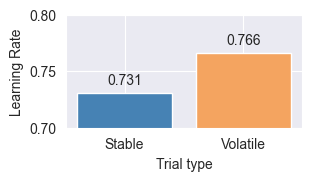

In [232]:
# Data
models = ['Stable', 'Volatile']
learning_rates = [0.731, 0.766]

colours = ['steelblue', 'sandybrown']

# Create the barplot
fig, ax = plt.subplots(figsize=(3, 1.7), constrained_layout=True)
plt.bar(models, learning_rates, color=colours)

# Add labels and title
plt.xlabel('Trial type')
plt.ylabel('Learning Rate')
plt.ylim(0.7, 0.8)

# Annotate bars with values
for index, value in enumerate(learning_rates):
    plt.text(index, value + 0.005, f"{value}", ha='center', va='bottom')

# Show the plot
plt.savefig(os.path.join(presentations_output_dir, f'barplot_learning.pdf'))
plt.show()

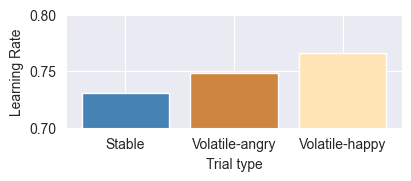

In [233]:
# Data
models = ['Stable', 'Volatile-angry', 'Volatile-happy']
learning_rates = [0.731, 0.7485, 0.766]

colours = ['steelblue', 'peru', 'moccasin']

# Create the barplot
fig, ax = plt.subplots(figsize=(4, 1.7), constrained_layout=True)
plt.bar(models, learning_rates, color=colours)

# Add labels and title
plt.xlabel('Trial type')
plt.ylabel('Learning Rate')
plt.ylim(0.7, 0.8)

# Show the plot
plt.savefig(os.path.join(presentations_output_dir, f'barplot_learning_valence.pdf'))
plt.show()

# Plot the rows since a switch

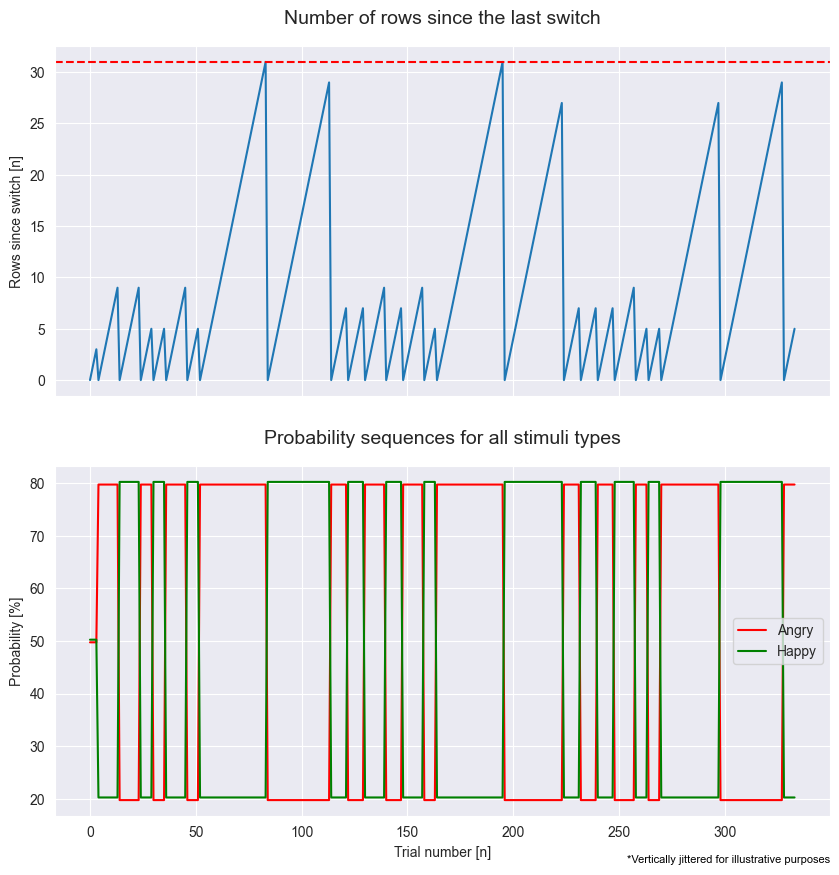

In [234]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True, sharey=False)
stimuli_type_names = ['Angry','Happy']
group_colours = ['red','green']

# Plot the time since the last switch
max_rows_since_change = probability_dataframe_pivoted['rows_since_change'].max()
ax1.plot(probability_dataframe_pivoted['rows_since_change'])
ax1.axhline(max_rows_since_change, color='r', linestyle='--', label='Max rows before switch')
ax1.set_title('Number of rows since the last switch', fontsize=14, y=1.04)
ax1.set_ylabel('Rows since switch [n]')

# Plot all stimuli types together
for index, value in enumerate(unique_stimuli_types):
    column_data = probability_dataframe_pivoted[value] + jitter_strength[index-1]
    ax2.plot(column_data, label=stimuli_type_names[value-1], color=group_colours[value-1])
ax2.set_title('Probability sequences for all stimuli types', fontsize=14, y=1.04)
ax2.set_xlabel('Trial number [n]')
ax2.set_ylabel('Probability [%]')
ax2.legend()
ax2.text(1, -0.14, note, transform=ax2.transAxes, horizontalalignment='right', verticalalignment='bottom',
        fontsize=8, color='black')
plt.savefig(os.path.join(output_dir, f'probability_sequence_with_time_since_switch_all_stimuli_types_sub-{subject_id[0]:003}_session-{session_number[0]:02}.pdf'))
plt.show()